# 🧠 K-Means Mastery — Credit Card Customer Segmentation
**Dataset:** `CC GENERAL.csv` — 8,950 credit card customers | 18 features

---
| Step | Topic |
|------|-------|
| ✅ 1 | Theory & Intuition *(covered — see chat)* |
| 📊 2 | Exploratory Data Analysis (EDA) |
| 🔧 3 | Data Preprocessing & Scaling |
| 🔢 4 | Finding Optimal K (Elbow + Silhouette) |
| 🤖 5 | Fit the K-Means Model |
| 🔍 6 | Analyse & Profile Clusters |
| 🎨 7 | Visualise Clusters (PCA + Heatmap) |
| 💡 8 | Business Insights |

---
## 📊 STEP 2 — Exploratory Data Analysis (EDA)
> **Goal:** Understand the data before modelling — distributions, missing values, correlations, outliers.

### 2.1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Global plot style ─────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    
    'axes.edgecolor':   '#3a3f5c',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#b0b0b0',
    'ytick.color':      '#b0b0b0',
    'text.color':       '#e0e0e0',
    'grid.color':       '#2a2d3e',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
})
PALETTE = ['#7C83FD','#96FAFA','#FF6B6B','#FFD93D','#6BCB77','#FF922B','#CC5DE8','#74C0FC']
print('✅ Libraries loaded!')

✅ Libraries loaded!


### 2.2 — Load Data & Basic Overview

In [2]:
df = pd.read_csv('CC GENERAL.csv')

print(f"Shape  : {df.shape[0]:,} rows  ×  {df.shape[1]} columns")
print(f"Memory : {df.memory_usage(deep=True).sum()/1024:.1f} KB")
df.head()

Shape  : 8,950 rows  ×  18 columns
Memory : 1669.5 KB


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
# Data types and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [4]:
# Statistical summary — count, mean, std, min, quartiles, max
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.000000,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.138560
BALANCE_FREQUENCY,8950.000000,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.000000
PURCHASES,8950.000000,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.570000
ONEOFF_PURCHASES,8950.000000,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.250000
INSTALLMENTS_PURCHASES,8950.000000,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.000000
CASH_ADVANCE,8950.000000,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.211760
PURCHASES_FREQUENCY,8950.000000,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.000000
ONEOFF_PURCHASES_FREQUENCY,8950.000000,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.000000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.000000,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.000000
CASH_ADVANCE_FREQUENCY,8950.000000,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.500000


### 2.3 — Missing Values

Columns with missing values:


,Missing Count,Missing %
CREDIT_LIMIT,1,0.01
MINIMUM_PAYMENTS,313,3.50


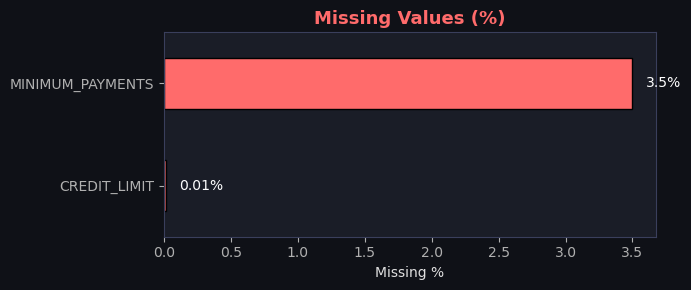

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
mv = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
mv = mv[mv['Missing Count'] > 0]

print("Columns with missing values:")
display(mv)

# Visual bar
fig, ax = plt.subplots(figsize=(7, 3), facecolor='#0f1117')
mv['Missing %'].plot(kind='barh', ax=ax, color='#FF6B6B', edgecolor='black')
ax.set_title('Missing Values (%)', fontsize=13, fontweight='bold', color='#FF6B6B')
ax.set_xlabel('Missing %')
for i, v in enumerate(mv['Missing %']):
    ax.text(v + 0.1, i, f'{v}%', va='center', color='white', fontsize=10)
plt.tight_layout()
plt.show()

### 2.4 — Feature Distributions (Histograms)
> The white dashed line = **median**. Notice most features are **right-skewed** — this is why we'll need to scale them.

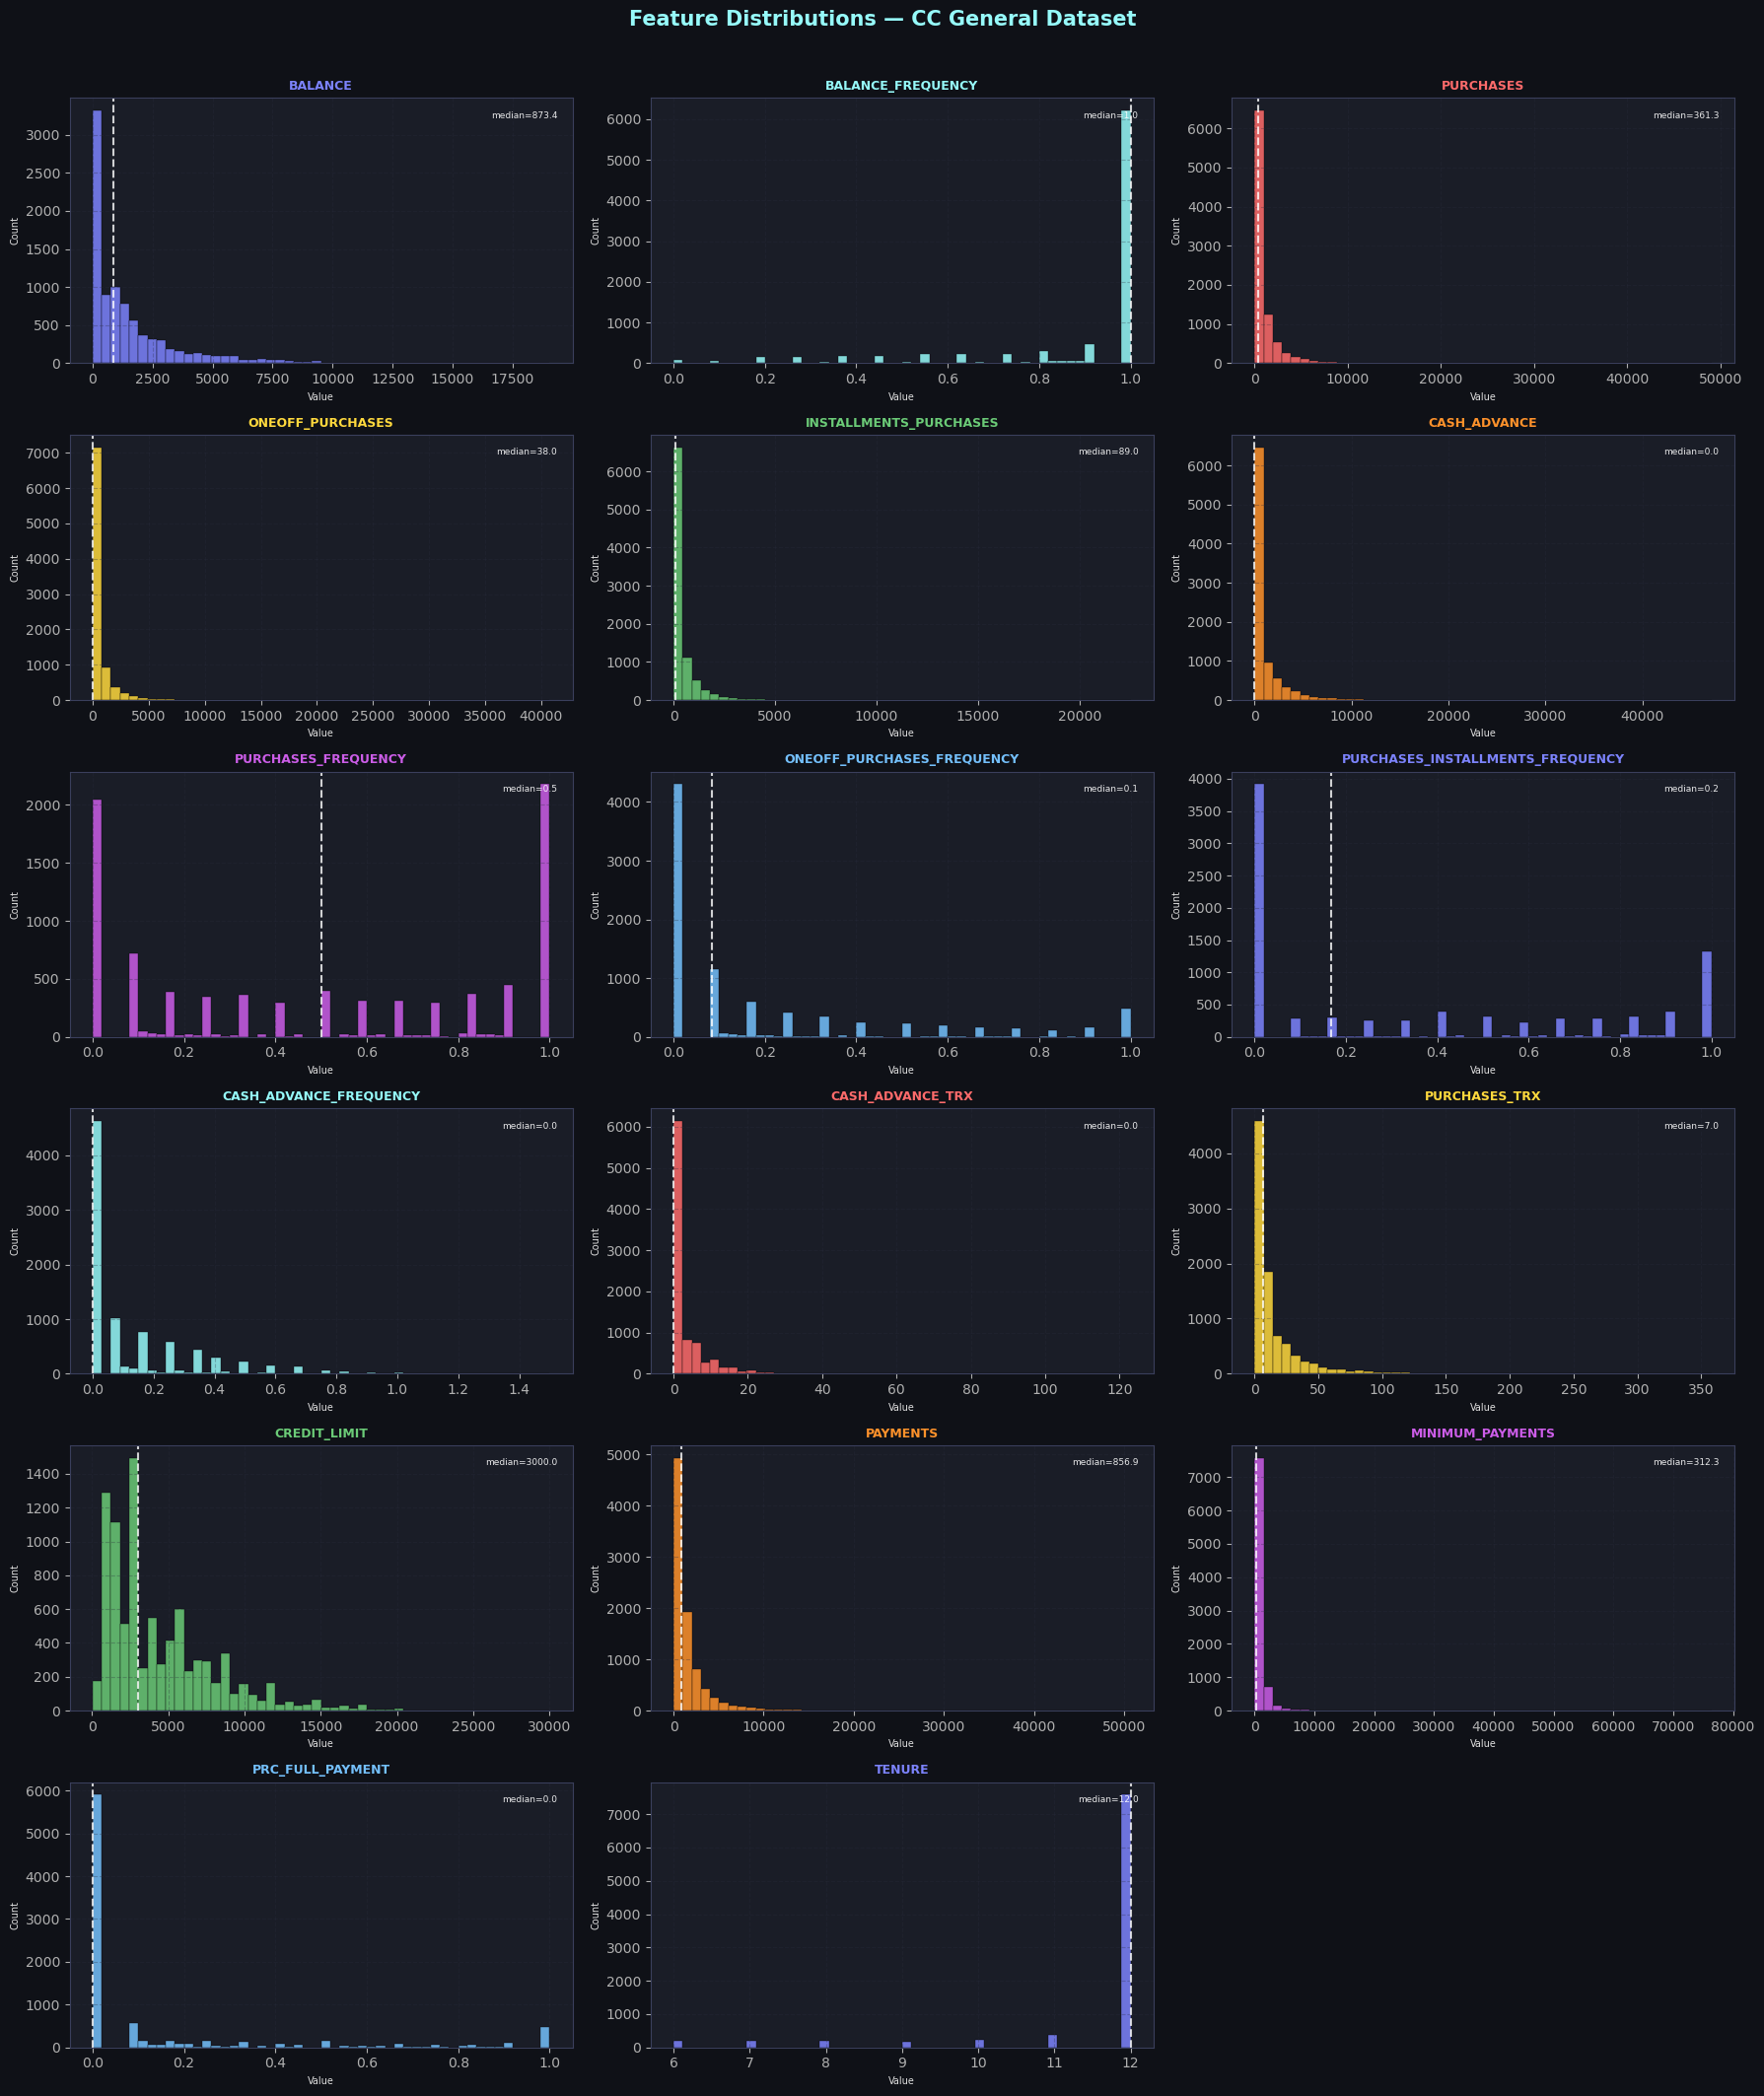

In [6]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
n_cols = 3
n_rows = -(-len(numeric_cols) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*3.5), facecolor='#0f1117')
fig.suptitle('Feature Distributions — CC General Dataset',
             fontsize=15, fontweight='bold', color='#96FAFA', y=1.01)

axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    ax = axes[i]
    color = PALETTE[i % len(PALETTE)]
    ax.hist(df[col].dropna(), bins=50, color=color, alpha=0.85, edgecolor='black', linewidth=0.3)
    ax.set_title(col, fontsize=9, fontweight='bold', color=color)
    ax.set_xlabel('Value', fontsize=7)
    ax.set_ylabel('Count', fontsize=7)
    ax.grid(True, alpha=0.3)
    median_val = df[col].median()
    ax.axvline(median_val, color='white', linewidth=1.5, linestyle='--', alpha=0.8)
    ax.text(0.97, 0.95, f'median={median_val:.1f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=6.5, color='white', alpha=0.9)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 2.5 — Correlation Heatmap
> Values close to **+1** = strong positive correlation | close to **-1** = strong negative | **0** = no relationship.

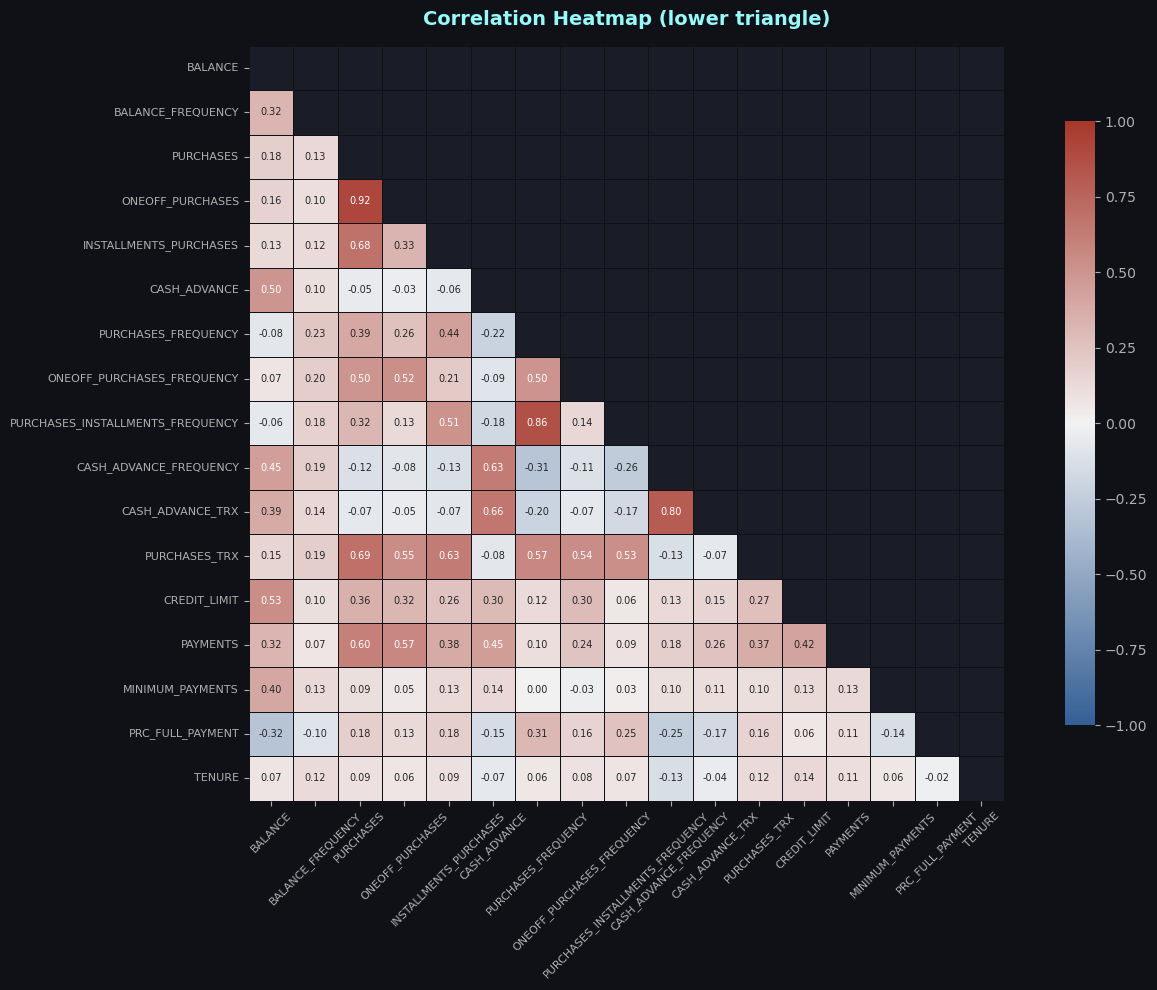


🔗 Strongest correlations (|r| ≥ 0.5):
  ↑↑  ONEOFF_PURCHASES  ↔  PURCHASES  →  r = 0.92
  ↑↑  PURCHASES_INSTALLMENTS_FREQUENCY  ↔  PURCHASES_FREQUENCY  →  r = 0.86
  ↑↑  CASH_ADVANCE_TRX  ↔  CASH_ADVANCE_FREQUENCY  →  r = 0.8
  ↑↑  PURCHASES_TRX  ↔  PURCHASES  →  r = 0.69
  ↑↑  INSTALLMENTS_PURCHASES  ↔  PURCHASES  →  r = 0.68
  ↑↑  CASH_ADVANCE_TRX  ↔  CASH_ADVANCE  →  r = 0.66
  ↑↑  CASH_ADVANCE_FREQUENCY  ↔  CASH_ADVANCE  →  r = 0.63
  ↑↑  PURCHASES_TRX  ↔  INSTALLMENTS_PURCHASES  →  r = 0.63
  ↑↑  PAYMENTS  ↔  PURCHASES  →  r = 0.6
  ↑↑  PURCHASES_TRX  ↔  PURCHASES_FREQUENCY  →  r = 0.57
  ↑↑  PAYMENTS  ↔  ONEOFF_PURCHASES  →  r = 0.57
  ↑↑  PURCHASES_TRX  ↔  ONEOFF_PURCHASES  →  r = 0.55
  ↑↑  PURCHASES_TRX  ↔  ONEOFF_PURCHASES_FREQUENCY  →  r = 0.54
  ↑↑  PURCHASES_TRX  ↔  PURCHASES_INSTALLMENTS_FREQUENCY  →  r = 0.53
  ↑↑  CREDIT_LIMIT  ↔  BALANCE  →  r = 0.53
  ↑↑  ONEOFF_PURCHASES_FREQUENCY  ↔  ONEOFF_PURCHASES  →  r = 0.52
  ↑↑  PURCHASES_INSTALLMENTS_FREQUENCY  ↔  INSTALLME

In [7]:
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle
cmap = sns.diverging_palette(250, 15, s=75, l=40, as_cmap=True)

fig, ax = plt.subplots(figsize=(14, 10), facecolor='#0f1117')
sns.heatmap(corr, mask=mask, cmap=cmap, center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.4, linecolor='#0f1117',
            square=True, ax=ax, cbar_kws={'shrink': 0.8})

ax.set_title('Correlation Heatmap (lower triangle)', fontsize=14, fontweight='bold', color='#96FAFA', pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.show()

# Print the strongest correlations
print("\n🔗 Strongest correlations (|r| ≥ 0.5):")
high = []
for i in range(len(corr.columns)):
    for j in range(i):
        r = corr.iloc[i,j]
        if abs(r) >= 0.5:
            high.append((corr.columns[i], corr.columns[j], round(r,2)))
for a,b,r in sorted(high, key=lambda x: abs(x[2]), reverse=True):
    arrow = '↑↑' if r>0 else '↑↓'
    print(f"  {arrow}  {a}  ↔  {b}  →  r = {r}")

### 2.6 — Boxplots (Outlier Detection)
> Dots beyond the whiskers = **outliers** (IQR rule). Heavy outliers are why we scale data before K-Means!

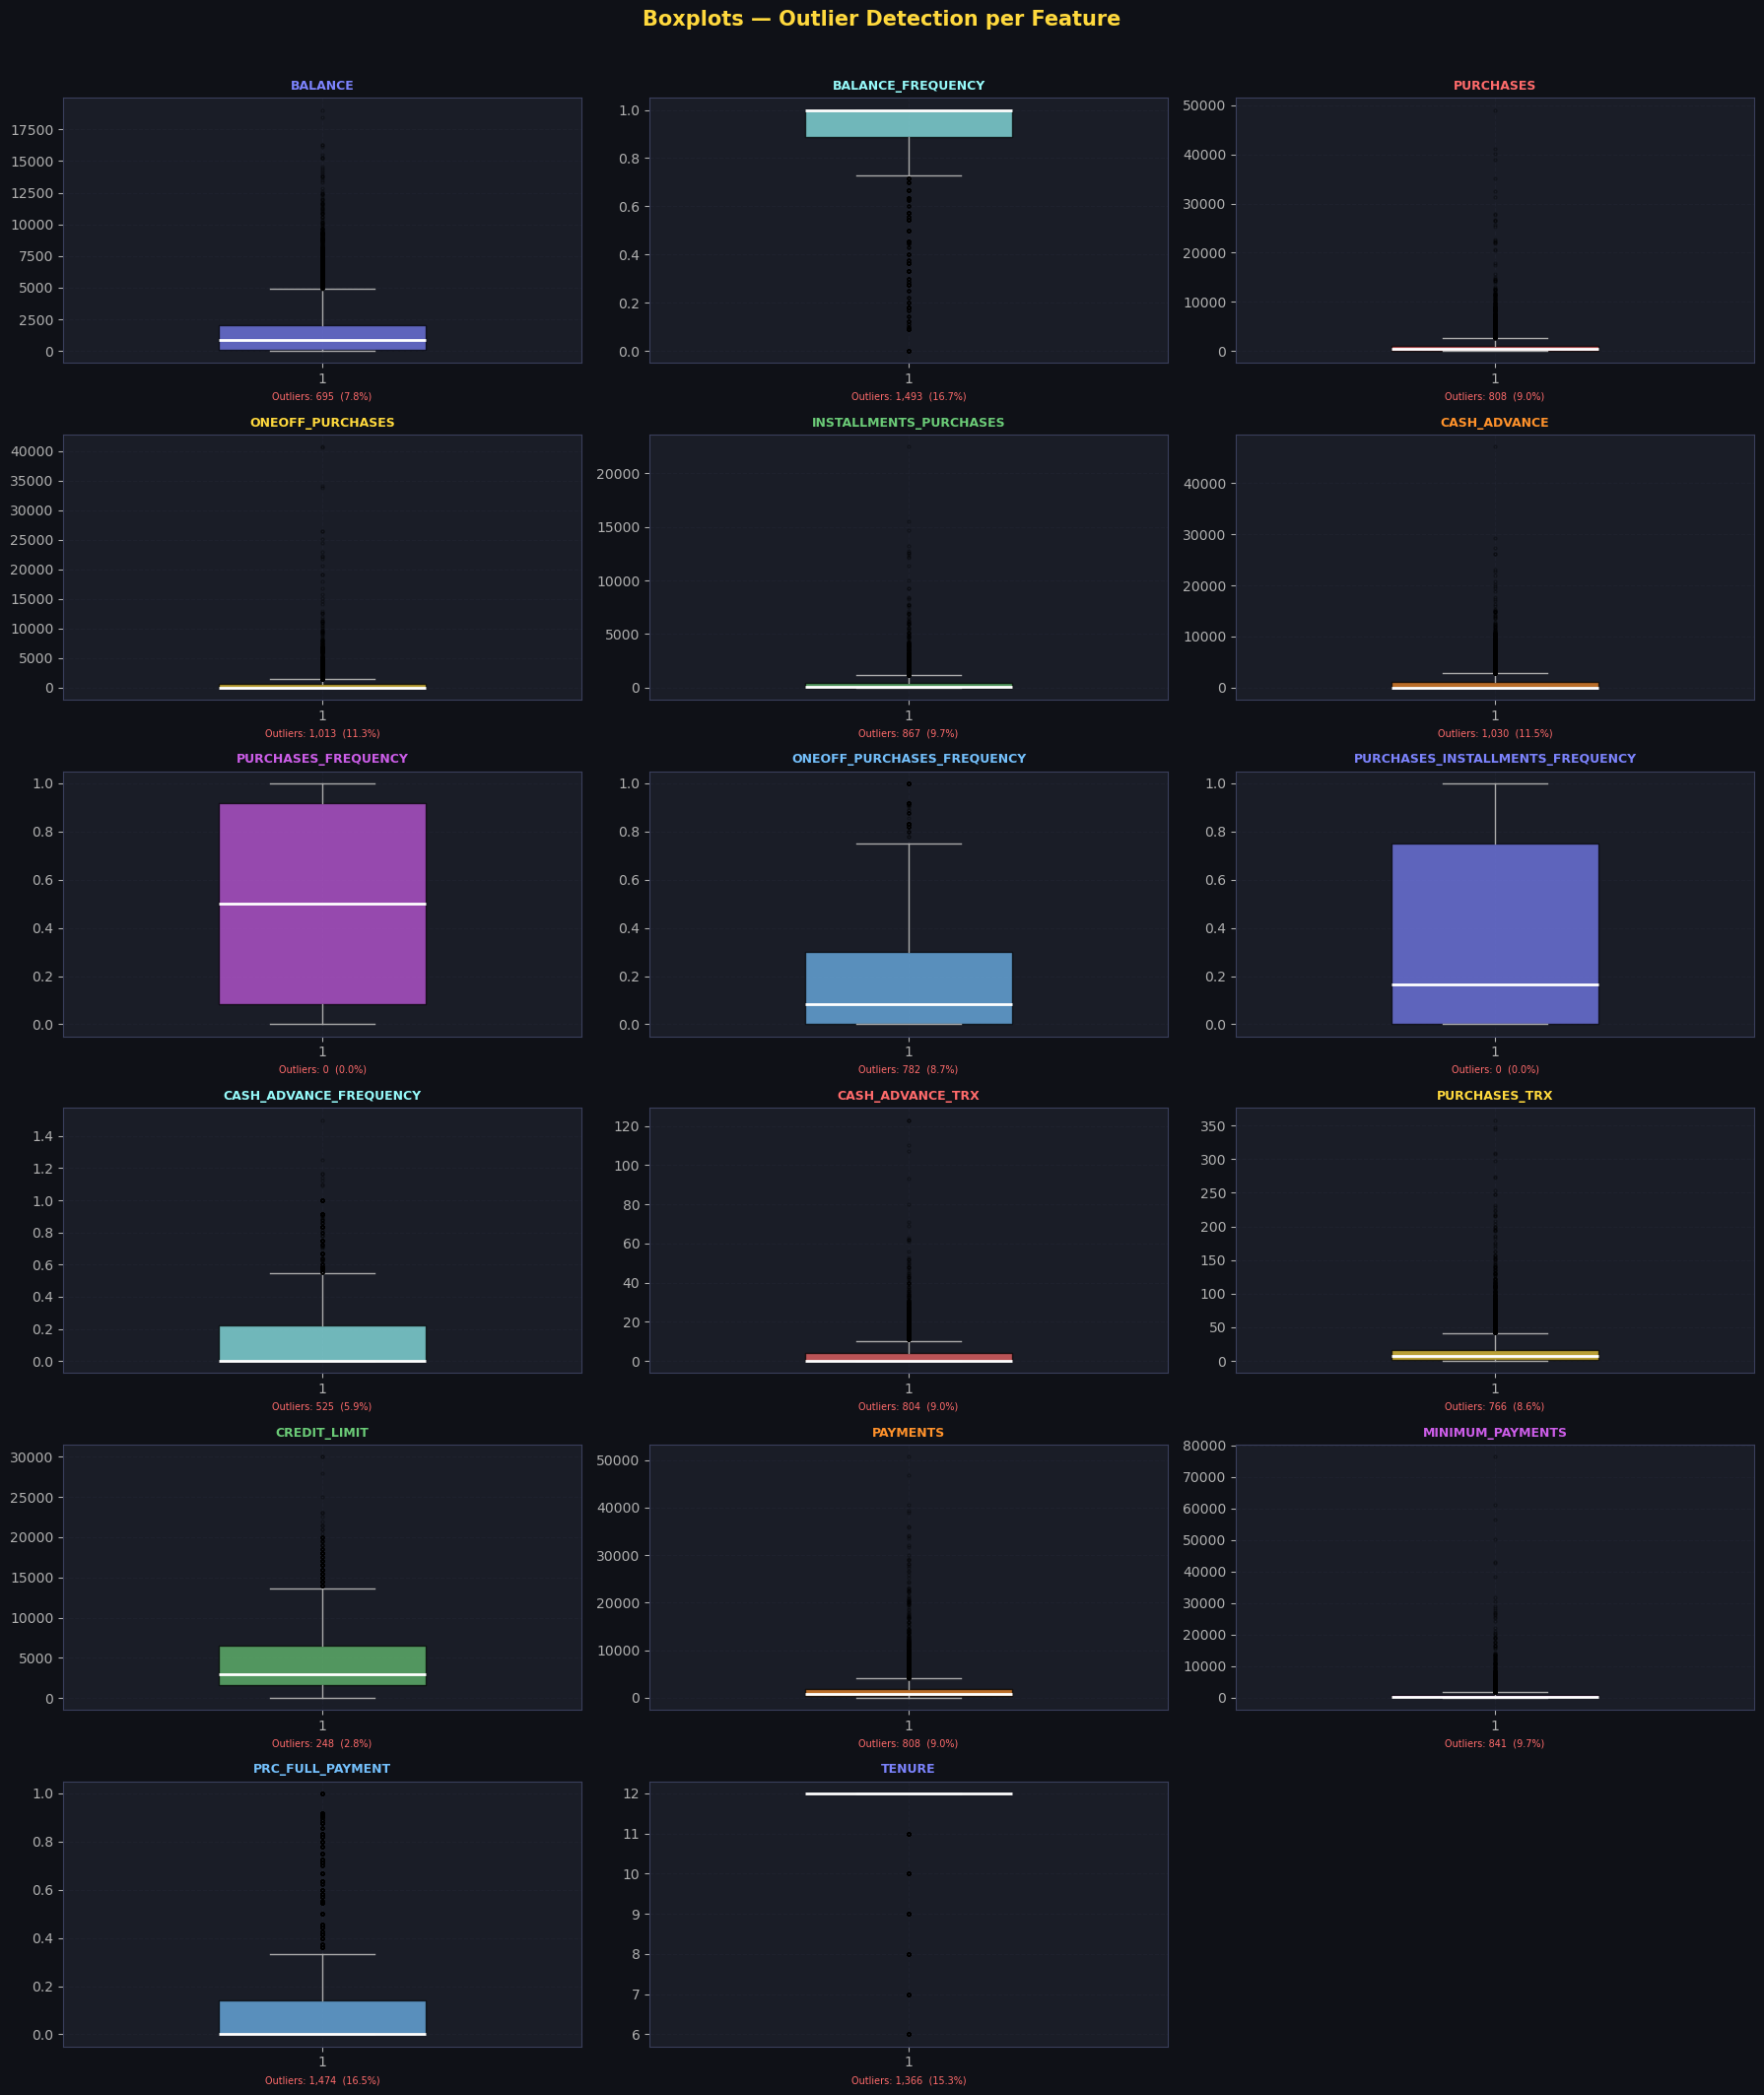

In [8]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*3.5), facecolor='#0f1117')
fig.suptitle('Boxplots — Outlier Detection per Feature',
             fontsize=15, fontweight='bold', color='#FFD93D', y=1.01)

axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    ax = axes[i]
    color = PALETTE[i % len(PALETTE)]
    data = df[col].dropna()
    bp = ax.boxplot(data, patch_artist=True, vert=True, widths=0.4,
                    medianprops=dict(color='white', linewidth=2))
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.7)
    for w in bp['whiskers']: w.set(color='#aaaaaa', linewidth=1)
    for c in bp['caps']:     c.set(color='#aaaaaa', linewidth=1)
    for f in bp['fliers']:   f.set(marker='o', color=color, alpha=0.3, markersize=2)
    ax.set_title(col, fontsize=9, fontweight='bold', color=color)
    ax.grid(True, alpha=0.3)
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((data < Q1-1.5*IQR) | (data > Q3+1.5*IQR)).sum()
    ax.set_xlabel(f'Outliers: {n_out:,}  ({n_out/len(data)*100:.1f}%)', fontsize=7, color='#FF6B6B')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### ✅ EDA Summary
| Finding | Detail |
|---------|--------|
| Missing values | `CREDIT_LIMIT` (1 row), `MINIMUM_PAYMENTS` (313 rows) → will impute with **median** |
| Skewness | Most features are **right-skewed** → **StandardScaler** needed |
| Outliers | `CASH_ADVANCE`, `PURCHASES`, `BALANCE` have heavy outliers |
| Strong correlations | `PURCHASES` ↔ `PURCHASES_TRX` (r≈0.69), `CASH_ADVANCE` ↔ `CASH_ADVANCE_TRX` (r≈0.64) |

---
## 🔧 STEP 3 — Data Preprocessing & Scaling
> **Goal:** Clean the data and put all features on the same scale so K-Means treats them equally.

### 3.1 — Why Do We Scale?

K-Means uses **Euclidean distance**. If one feature ranges from 0–50,000 (`BALANCE`) and another from 0–1 (`PRC_FULL_PAYMENT`), the large-scale feature will **dominate** the distance calculation — the small feature gets ignored!

**StandardScaler** transforms each feature to have:
- **mean = 0**
- **std = 1**

```
z = (x - mean) / std
```

In [9]:
from sklearn.preprocessing import StandardScaler

# ── 3.2 Handle Missing Values ──────────────────────────────────────
df_clean = df.copy()

# Fill with median (robust to outliers vs. mean)
df_clean['CREDIT_LIMIT'].fillna(df_clean['CREDIT_LIMIT'].median(), inplace=True)
df_clean['MINIMUM_PAYMENTS'].fillna(df_clean['MINIMUM_PAYMENTS'].median(), inplace=True)

print(f"Missing values after imputation: {df_clean.isnull().sum().sum()}  ✅")

# ── 3.3 Drop ID Column ─────────────────────────────────────────────
df_clean.drop(columns=['CUST_ID'], inplace=True)
print(f"Shape after dropping CUST_ID  : {df_clean.shape}")

Missing values after imputation: 0  ✅
Shape after dropping CUST_ID  : (8950, 17)


In [10]:
# ── 3.4 Scale Features ────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

# Wrap back in DataFrame for easy reading
df_scaled = pd.DataFrame(X_scaled, columns=df_clean.columns)

print("After scaling — mean and std per feature:")
summary = pd.DataFrame({
    'Before Mean':  df_clean.mean().round(2),
    'Before Std':   df_clean.std().round(2),
    'After Mean':   df_scaled.mean().round(4),
    'After Std':    df_scaled.std().round(4)
})
display(summary.style.background_gradient(cmap='RdYlGn', axis=None, subset=['After Mean','After Std']))

After scaling — mean and std per feature:


,Before Mean,Before Std,After Mean,After Std
BALANCE,1564.470000,2081.530000,-0.000000,1.000100
BALANCE_FREQUENCY,0.880000,0.240000,0.000000,1.000100
PURCHASES,1003.200000,2136.630000,0.000000,1.000100
ONEOFF_PURCHASES,592.440000,1659.890000,-0.000000,1.000100
INSTALLMENTS_PURCHASES,411.070000,904.340000,0.000000,1.000100
CASH_ADVANCE,978.870000,2097.160000,-0.000000,1.000100
PURCHASES_FREQUENCY,0.490000,0.400000,0.000000,1.000100
ONEOFF_PURCHASES_FREQUENCY,0.200000,0.300000,0.000000,1.000100
PURCHASES_INSTALLMENTS_FREQUENCY,0.360000,0.400000,0.000000,1.000100
CASH_ADVANCE_FREQUENCY,0.140000,0.200000,-0.000000,1.000100


---
## 🔢 STEP 4 — Finding the Optimal K
> **Goal:** Use the **Elbow Method** and **Silhouette Score** to choose the best number of clusters.

### 4.1 — What is the Elbow Method?

We run K-Means for **K = 2, 3, 4, … 12** and plot how **Inertia (WCSS)** changes.

- As K increases → Inertia always **decreases** (more clusters = tighter fit)
- We look for the **"elbow"** — the point where inertia stops dropping sharply
- That elbow = our best K ✅

### 4.2 — What is the Silhouette Score?
Measures how similar a point is to its **own cluster vs. other clusters**:
- **+1** = perfectly clustered
- **0**  = on the boundary between clusters
- **-1** = assigned to the wrong cluster

We pick K with the **highest Silhouette Score**.

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_range = range(2, 13)
inertias   = []
sil_scores = []

print('Testing K values... (this takes ~30 seconds)')
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, km.labels_, sample_size=2000, random_state=42)
    sil_scores.append(sil)
    print(f'  K={k:>2}  |  Inertia={km.inertia_:>12,.1f}  |  Silhouette={sil:.4f}')

print('\n✅ Done!')

Testing K values... (this takes ~30 seconds)
  K= 2  |  Inertia=   127,784.5  |  Silhouette=0.2157
  K= 3  |  Inertia=   111,975.0  |  Silhouette=0.2403
  K= 4  |  Inertia=    99,061.9  |  Silhouette=0.2004
  K= 5  |  Inertia=    91,490.5  |  Silhouette=0.1975
  K= 6  |  Inertia=    84,826.6  |  Silhouette=0.2054
  K= 7  |  Inertia=    79,856.2  |  Silhouette=0.2108
  K= 8  |  Inertia=    74,484.9  |  Silhouette=0.2252
  K= 9  |  Inertia=    69,828.7  |  Silhouette=0.2277
  K=10  |  Inertia=    66,466.4  |  Silhouette=0.2224
  K=11  |  Inertia=    63,615.0  |  Silhouette=0.2155
  K=12  |  Inertia=    61,334.7  |  Silhouette=0.2156

✅ Done!


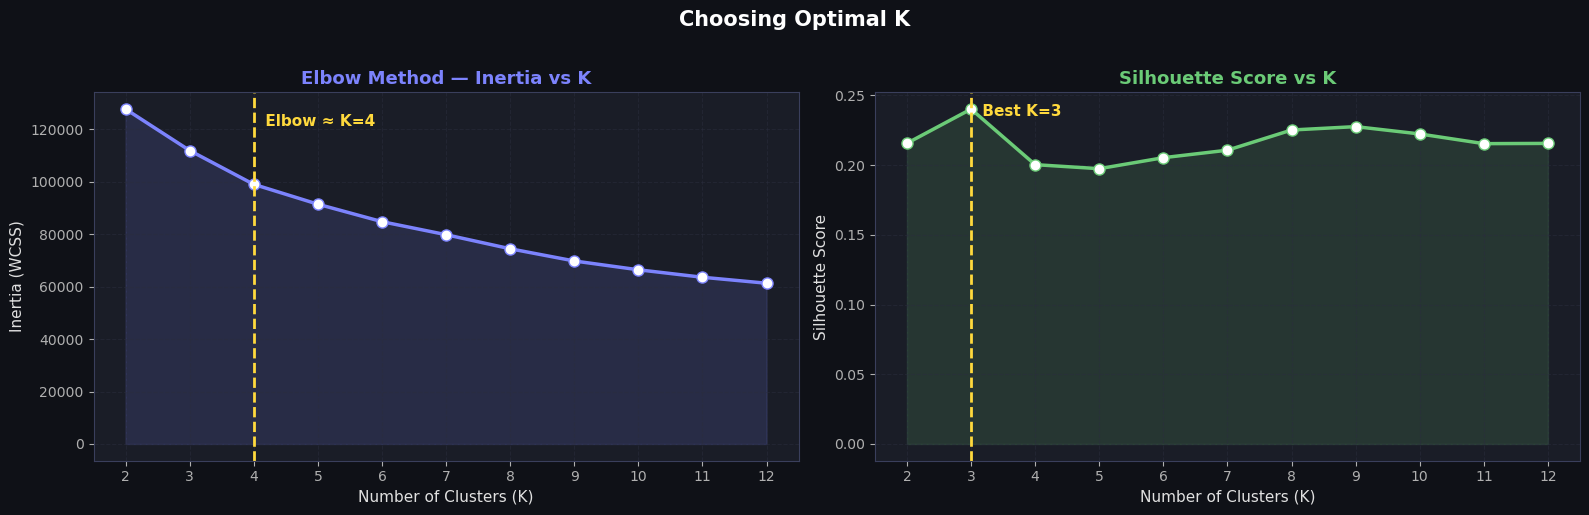


📌 Elbow suggests  : K = 4
📌 Silhouette best : K = 3  (score = 0.2403)

👉 We will use K = 3


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), facecolor='#0f1117')

k_list = list(K_range)

# ── Elbow Curve ──────────────────────────────────────────────────
ax1.plot(k_list, inertias, 'o-', color='#7C83FD', linewidth=2.5, markersize=8, markerfacecolor='white')
ax1.fill_between(k_list, inertias, alpha=0.15, color='#7C83FD')
ax1.set_title('Elbow Method — Inertia vs K', fontsize=13, fontweight='bold', color='#7C83FD')
ax1.set_xlabel('Number of Clusters (K)', fontsize=11)
ax1.set_ylabel('Inertia (WCSS)', fontsize=11)
ax1.set_xticks(k_list)
ax1.grid(True)

# Best K annotation on elbow
best_k_elbow = 4   # visually inspect and update if needed
ax1.axvline(best_k_elbow, color='#FFD93D', linewidth=2, linestyle='--')
ax1.text(best_k_elbow+0.1, max(inertias)*0.95, f' Elbow ≈ K={best_k_elbow}',
         color='#FFD93D', fontsize=11, fontweight='bold')

# ── Silhouette Score ─────────────────────────────────────────────
ax2.plot(k_list, sil_scores, 'o-', color='#6BCB77', linewidth=2.5, markersize=8, markerfacecolor='white')
ax2.fill_between(k_list, sil_scores, alpha=0.15, color='#6BCB77')
ax2.set_title('Silhouette Score vs K', fontsize=13, fontweight='bold', color='#6BCB77')
ax2.set_xlabel('Number of Clusters (K)', fontsize=11)
ax2.set_ylabel('Silhouette Score', fontsize=11)
ax2.set_xticks(k_list)
ax2.grid(True)

best_k_sil = k_list[sil_scores.index(max(sil_scores))]
ax2.axvline(best_k_sil, color='#FFD93D', linewidth=2, linestyle='--')
ax2.text(best_k_sil+0.1, max(sil_scores)*0.98, f' Best K={best_k_sil}',
         color='#FFD93D', fontsize=11, fontweight='bold')

plt.suptitle('Choosing Optimal K', fontsize=15, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n📌 Elbow suggests  : K = {best_k_elbow}")
print(f"📌 Silhouette best : K = {best_k_sil}  (score = {max(sil_scores):.4f})")
print(f"\n👉 We will use K = {best_k_sil}")

---
## 🤖 STEP 5 — Fit the K-Means Model
> **Goal:** Train the final K-Means model and assign every customer to a cluster.

### Why `init='k-means++'`?
Standard K-Means initialises centroids **randomly** — sometimes leading to bad results.

**K-Means++** places the first centroid randomly, then picks subsequent centroids **as far as possible** from existing ones. This gives:
- Faster convergence ⚡
- More consistent results 🎯
- Lower final inertia 📉

In [13]:
# ── Use the best K found above ───────────────────────────────────
BEST_K = best_k_sil   # automatically uses the silhouette best K

kmeans = KMeans(
    n_clusters  = BEST_K,
    init        = 'k-means++',   # smart initialisation
    n_init      = 10,            # run 10 times, keep best result
    max_iter    = 300,           # max iterations per run
    random_state= 42             # reproducibility
)

kmeans.fit(X_scaled)

# Assign cluster labels to original (unscaled) dataframe
df_clean['Cluster'] = kmeans.labels_

print(f"✅ K-Means fitted with K = {BEST_K}")
print(f"   Final Inertia   : {kmeans.inertia_:,.2f}")
print(f"   Iterations used : {kmeans.n_iter_}")
print(f"\nCluster sizes:")
print(df_clean['Cluster'].value_counts().sort_index().to_string())

✅ K-Means fitted with K = 3
   Final Inertia   : 111,975.04
   Iterations used : 27

Cluster sizes:
Cluster
0    1275
1    6114
2    1561


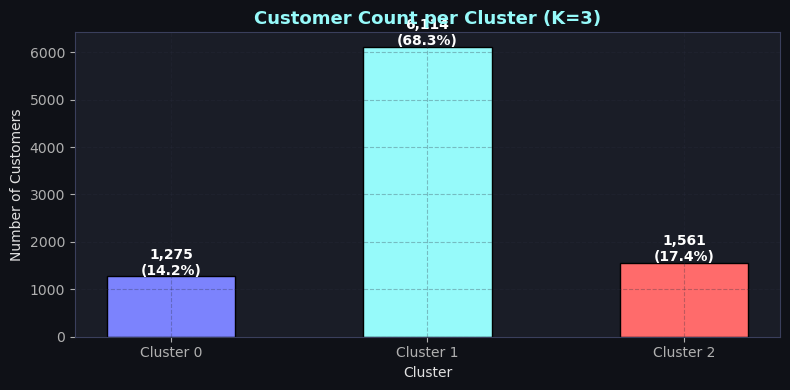

In [14]:
# Cluster size bar chart
sizes = df_clean['Cluster'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4), facecolor='#0f1117')
bars = ax.bar(sizes.index, sizes.values, color=PALETTE[:BEST_K], edgecolor='black', width=0.5)
ax.set_title(f'Customer Count per Cluster (K={BEST_K})', fontsize=13, fontweight='bold', color='#96FAFA')
ax.set_xlabel('Cluster')
ax.set_ylabel('Number of Customers')
ax.set_xticks(sizes.index)
ax.set_xticklabels([f'Cluster {i}' for i in sizes.index])
for bar, val in zip(bars, sizes.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}\n({val/len(df_clean)*100:.1f}%)', ha='center',
            color='white', fontsize=10, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 🔍 STEP 6 — Analyse & Profile Clusters
> **Goal:** Find the mean of each feature per cluster to understand what makes each group unique.

In [15]:
# Cluster means (on original scale — easier to interpret)
cluster_profile = df_clean.groupby('Cluster').mean().round(2).T
cluster_profile.columns = [f'Cluster {c}' for c in cluster_profile.columns]

display(cluster_profile.style
        .background_gradient(cmap='RdYlGn', axis=1)
        .format('{:.2f}'))

,Cluster 0,Cluster 1,Cluster 2
BALANCE,2182.35,807.72,4023.79
BALANCE_FREQUENCY,0.98,0.83,0.96
PURCHASES,4187.02,496.06,389.05
ONEOFF_PURCHASES,2664.00,247.27,252.33
INSTALLMENTS_PURCHASES,1523.49,249.11,136.80
CASH_ADVANCE,449.75,339.00,3917.25
PURCHASES_FREQUENCY,0.95,0.46,0.23
ONEOFF_PURCHASES_FREQUENCY,0.66,0.13,0.11
PURCHASES_INSTALLMENTS_FREQUENCY,0.74,0.34,0.15
CASH_ADVANCE_FREQUENCY,0.06,0.07,0.45


In [16]:
# ── Key distinguishing features ───────────────────────────────────
key_features = ['BALANCE','PURCHASES','CASH_ADVANCE',
                'CREDIT_LIMIT','PAYMENTS','PRC_FULL_PAYMENT',
                'PURCHASES_FREQUENCY','TENURE']

profile_key = df_clean.groupby('Cluster')[key_features].mean().round(2)
print("Key Feature Profile per Cluster:")
display(profile_key.style
        .background_gradient(cmap='coolwarm', axis=0)
        .format('{:.2f}'))

Key Feature Profile per Cluster:


,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT,PURCHASES_FREQUENCY,TENURE
Cluster,,,,,,,,
0,2182.35,4187.02,449.75,7642.78,4075.53,0.30,0.95,11.92
1,807.72,496.06,339.00,3267.02,907.45,0.15,0.46,11.48
2,4023.79,389.05,3917.25,6729.47,3053.94,0.03,0.23,11.35


---
## 🎨 STEP 7 — Visualise Clusters
> **Goal:** Use **PCA** to reduce 17 dimensions → 2D so we can plot and see the clusters visually.

### What is PCA?

**Principal Component Analysis (PCA)** is a dimensionality reduction technique.

Our data has 17 features (17 dimensions) — impossible to plot! PCA compresses this into **2 new components** (PC1 and PC2) that capture the **most variance** in the data.

```
17 features  →  PCA  →  2 components  →  2D scatter plot  ✅
```

> PCA is only for **visualisation** here — K-Means was trained on all 17 features.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_ * 100
print(f"PC1 explains: {explained[0]:.1f}%  |  PC2 explains: {explained[1]:.1f}%")
print(f"Total variance captured: {sum(explained):.1f}%")

# PCA Scatter Plot
fig, ax = plt.subplots(figsize=(12, 8), facecolor='#0f1117')

for cluster in sorted(df_clean['Cluster'].unique()):
    mask = df_clean['Cluster'] == cluster
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=PALETTE[cluster], label=f'Cluster {cluster}',
               alpha=0.5, s=15, edgecolors='none')

# Plot centroids transformed to PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           c='white', s=250, marker='*',
           edgecolors='black', linewidth=1.5,
           zorder=5, label='Centroids')
for i, (cx, cy) in enumerate(centroids_pca):
    ax.annotate(f'C{i}', (cx, cy), textcoords='offset points',
                xytext=(8, 5), fontsize=11, fontweight='bold',
                color='white')

ax.set_title(f'K-Means Clusters (K={BEST_K}) — PCA 2D Projection',
             fontsize=14, fontweight='bold', color='#96FAFA')
ax.set_xlabel(f'PC1 ({explained[0]:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({explained[1]:.1f}% variance)', fontsize=11)
ax.legend(fontsize=10, framealpha=0.3)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

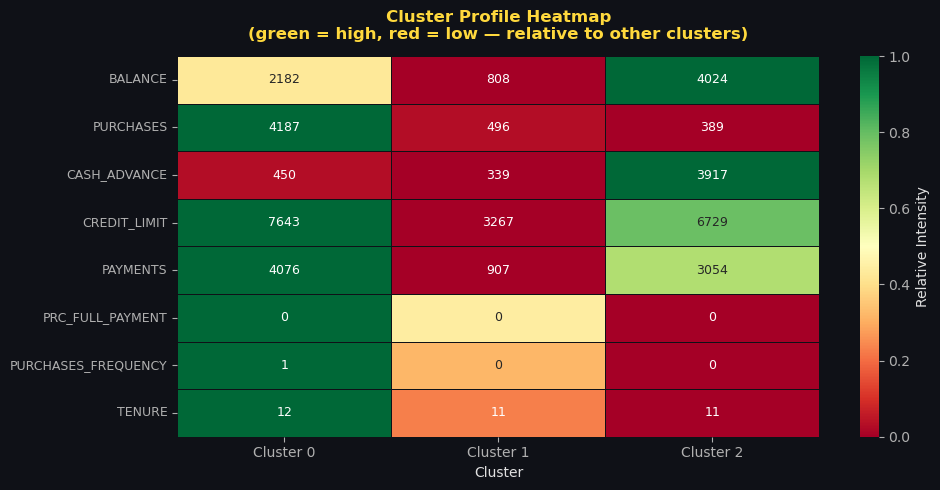

In [17]:
# ── Cluster Profile Heatmap (normalised for comparison) ──────────
profile_norm = (profile_key - profile_key.min()) / (profile_key.max() - profile_key.min())

fig, ax = plt.subplots(figsize=(10, 5), facecolor='#0f1117')
sns.heatmap(profile_norm.T,
            cmap='RdYlGn',
            annot=profile_key.T.round(0),
            fmt='.0f',
            annot_kws={'size': 9},
            linewidths=0.5,
            linecolor='#0f1117',
            ax=ax,
            cbar_kws={'label': 'Relative Intensity'})

ax.set_title('Cluster Profile Heatmap\n(green = high, red = low — relative to other clusters)',
             fontsize=12, fontweight='bold', color='#FFD93D', pad=12)
ax.set_xticklabels([f'Cluster {i}' for i in profile_key.index], fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

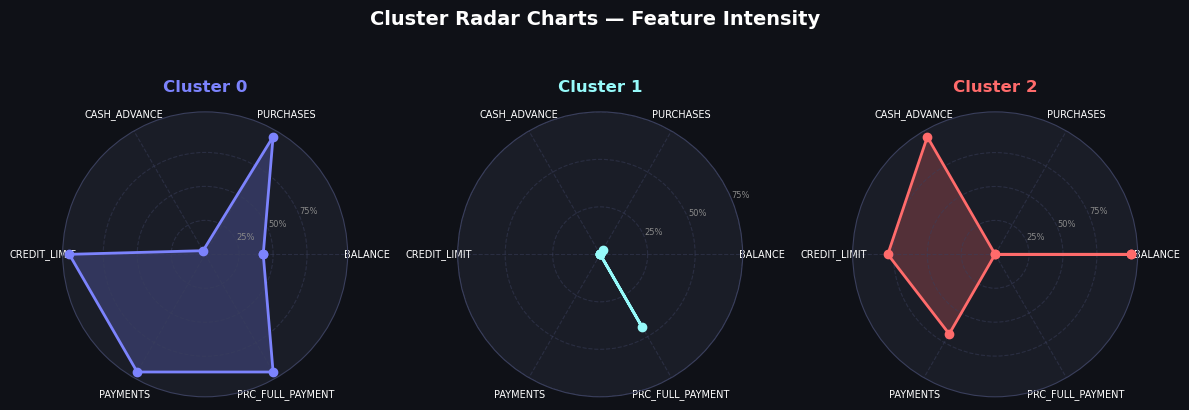

In [18]:
# ── Radar (Spider) Chart per Cluster ────────────────────────────
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

radar_features = ['BALANCE','PURCHASES','CASH_ADVANCE',
                  'CREDIT_LIMIT','PAYMENTS','PRC_FULL_PAYMENT']

# Normalise 0-1 for radar
radar_norm = profile_key[radar_features].copy()
for col in radar_features:
    radar_norm[col] = (radar_norm[col] - radar_norm[col].min()) / \
                      (radar_norm[col].max() - radar_norm[col].min() + 1e-9)

N = len(radar_features)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # close the polygon

fig, axes = plt.subplots(1, BEST_K,
                          figsize=(BEST_K * 4, 4),
                          subplot_kw=dict(polar=True),
                          facecolor='#0f1117')

if BEST_K == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    values = radar_norm.iloc[i].tolist()
    values += values[:1]
    color = PALETTE[i]
    ax.set_facecolor('#1a1d27')
    ax.plot(angles, values, 'o-', linewidth=2, color=color)
    ax.fill(angles, values, alpha=0.25, color=color)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_features, size=7, color='white')
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(['25%','50%','75%'], size=6, color='#888')
    ax.set_title(f'Cluster {i}', size=12, fontweight='bold', color=color, pad=15)
    ax.spines['polar'].set_color('#3a3f5c')
    ax.grid(color='#3a3f5c', linewidth=0.8)

fig.suptitle('Cluster Radar Charts — Feature Intensity', fontsize=14,
             fontweight='bold', color='white', y=1.05)
plt.tight_layout()
plt.show()

---
## 💡 STEP 8 — Business Insights
> **Goal:** Give each cluster a meaningful name and suggest real-world business actions.

In [19]:
# Review the cluster profile one more time to name clusters
print("===== CLUSTER PROFILE (Key Metrics) =====")
display(profile_key.style
        .background_gradient(cmap='RdYlGn', axis=0)
        .format('{:.2f}'))

print("\n" + "="*60)
print("📋 CLUSTER NAMING GUIDE")
print("="*60)
print("""
Look at the heatmap and profile above and assign a name to each cluster.
Some patterns to look for:

  HIGH BALANCE   + LOW PURCHASES      → 'Revolvers' (carry debt, spend little)
  HIGH PURCHASES + HIGH PAYMENTS      → 'Big Spenders' (spend & pay in full)
  HIGH CASH_ADVANCE + LOW PURCHASES   → 'Cash Advance Users'
  LOW BALANCE + LOW PURCHASES         → 'Inactive / VIP Low Use'
  HIGH PRC_FULL_PAYMENT               → 'Responsible Payers'
""")

===== CLUSTER PROFILE (Key Metrics) =====


,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT,PURCHASES_FREQUENCY,TENURE
Cluster,,,,,,,,
0,2182.35,4187.02,449.75,7642.78,4075.53,0.30,0.95,11.92
1,807.72,496.06,339.00,3267.02,907.45,0.15,0.46,11.48
2,4023.79,389.05,3917.25,6729.47,3053.94,0.03,0.23,11.35



📋 CLUSTER NAMING GUIDE

Look at the heatmap and profile above and assign a name to each cluster.
Some patterns to look for:

  HIGH BALANCE   + LOW PURCHASES      → 'Revolvers' (carry debt, spend little)
  HIGH PURCHASES + HIGH PAYMENTS      → 'Big Spenders' (spend & pay in full)
  HIGH CASH_ADVANCE + LOW PURCHASES   → 'Cash Advance Users'
  LOW BALANCE + LOW PURCHASES         → 'Inactive / VIP Low Use'
  HIGH PRC_FULL_PAYMENT               → 'Responsible Payers'



In [20]:
# ── MANUALLY UPDATE THESE NAMES after reviewing profiles above ──
# Format:  cluster_number: 'Name'
CLUSTER_NAMES = {
    0: 'Cluster 0 — (update after viewing profile)',
    1: 'Cluster 1 — (update after viewing profile)',
    2: 'Cluster 2 — (update after viewing profile)',
    3: 'Cluster 3 — (update after viewing profile)',
}

df_clean['Segment'] = df_clean['Cluster'].map(CLUSTER_NAMES)

print("Segment counts:")
print(df_clean['Segment'].value_counts().to_string())

Segment counts:
Segment
Cluster 1 — (update after viewing profile)    6114
Cluster 2 — (update after viewing profile)    1561
Cluster 0 — (update after viewing profile)    1275


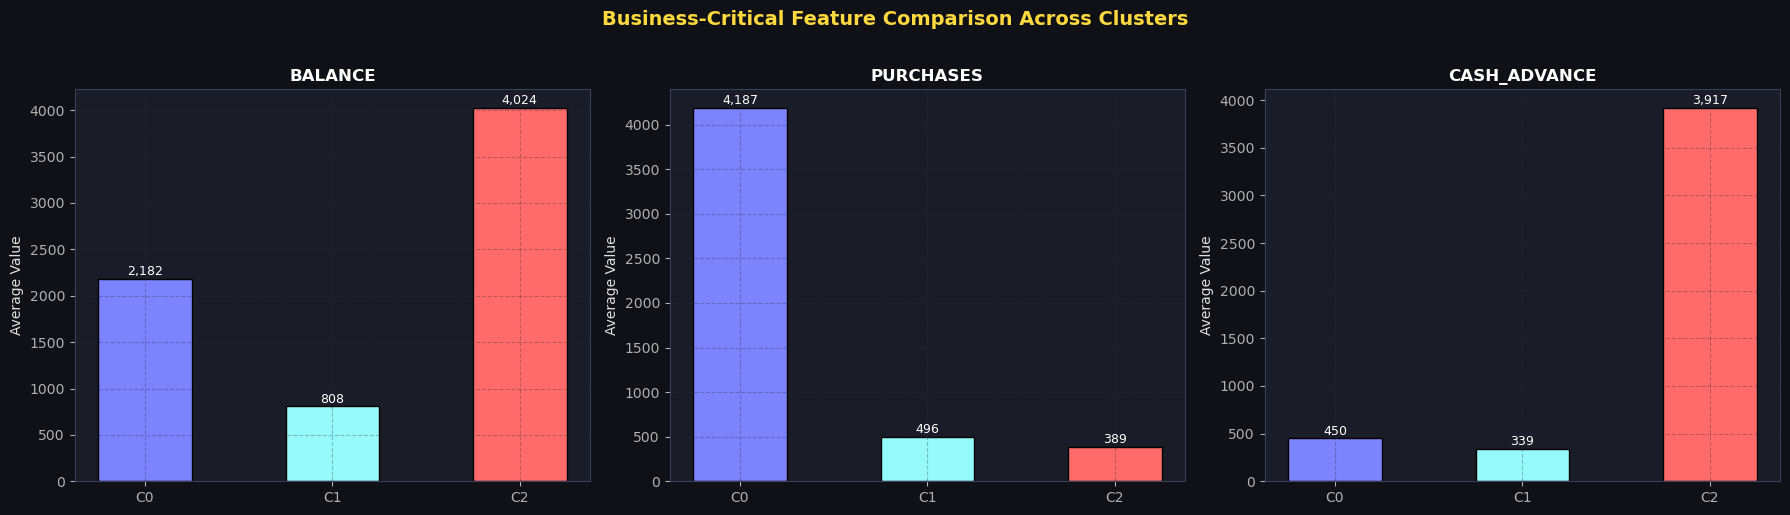

In [22]:
# ── Final Summary Visual ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='#0f1117')
compare_features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE']

for ax, feat in zip(axes, compare_features):
    vals = profile_key[feat]
    bars = ax.bar(range(BEST_K), vals.values,
                  color=PALETTE[:BEST_K], edgecolor='black', width=0.5)
    ax.set_title(feat, fontsize=12, fontweight='bold', color='white')
    ax.set_xticks(range(BEST_K))
    ax.set_xticklabels([f'C{i}' for i in range(BEST_K)])
    ax.set_ylabel('Average Value')
    ax.grid(True, alpha=0.3)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.01,
                f'{val:,.0f}', ha='center', color='white', fontsize=9)

fig.suptitle('Business-Critical Feature Comparison Across Clusters',
             fontsize=14, fontweight='bold', color='#FFD93D', y=1.02)
plt.tight_layout()
plt.show()

In [23]:
# ── Export final segmented dataset ───────────────────────────────
# Attach original CUST_ID back
df_final = df.copy()
df_final['Cluster'] = kmeans.labels_
df_final['Segment'] = df_final['Cluster'].map(CLUSTER_NAMES)

df_final.to_csv('CC_Segmented.csv', index=False)
print(f"✅ Segmented dataset saved: CC_Segmented.csv")
print(f"   Shape: {df_final.shape}")
df_final[['CUST_ID','BALANCE','PURCHASES','CASH_ADVANCE',
           'CREDIT_LIMIT','Cluster','Segment']].head(10)

✅ Segmented dataset saved: CC_Segmented.csv
   Shape: (8950, 20)


,CUST_ID,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,Cluster,Segment
0,C10001,40.900749,95.40,0.000000,1000.0,1,Cluster 1 — (update after viewing profile)
1,C10002,3202.467416,0.00,6442.945483,7000.0,2,Cluster 2 — (update after viewing profile)
2,C10003,2495.148862,773.17,0.000000,7500.0,1,Cluster 1 — (update after viewing profile)
3,C10004,1666.670542,1499.00,205.788017,7500.0,1,Cluster 1 — (update after viewing profile)
4,C10005,817.714335,16.00,0.000000,1200.0,1,Cluster 1 — (update after viewing profile)
5,C10006,1809.828751,1333.28,0.000000,1800.0,1,Cluster 1 — (update after viewing profile)
6,C10007,627.260806,7091.01,0.000000,13500.0,0,Cluster 0 — (update after viewing profile)
7,C10008,1823.652743,436.20,0.000000,2300.0,1,Cluster 1 — (update after viewing profile)
8,C10009,1014.926473,861.49,0.000000,7000.0,1,Cluster 1 — (update after viewing profile)
9,C10010,152.225975,1281.60,0.000000,11000.0,1,Cluster 1 — (update after viewing profile)
